In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)


In [3]:
from google.colab import drive
import zipfile

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Dataset extracted to:", BASE)


Mounted at /content/drive
Dataset extracted to: /content/dataset/Parkinson's Dataset Final


In [4]:
for root, dirs, files in os.walk(BASE):
    if "HandPD" in dirs or "NewHandPD" in dirs:
        print("FOUND:", root)
        print("Dirs:", dirs)
        break


In [6]:
HANDPD_ROOT = os.path.join(BASE, "Hand_Pd")
NEWHANDPD_ROOT = os.path.join(BASE, "New_hand_pd Dataset")

print("HandPD:", os.listdir(HANDPD_ROOT))
print("NewHandPD:", os.listdir(NEWHANDPD_ROOT))


FileNotFoundError: [Errno 2] No such file or directory: "/content/dataset/Parkinson's Dataset Final/Hand_Pd"

In [7]:
import os

print("Folders inside BASE:\n")
for item in os.listdir(BASE):
    path = os.path.join(BASE, item)
    if os.path.isdir(path):
        print("folder", item)


Folders inside BASE:

folder New hand pd Dataset
folder Hand Pd


In [8]:
HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

print("HandPD path:", HANDPD_ROOT)
print("NewHandPD path:", NEWHANDPD_ROOT)


HandPD path: /content/dataset/Parkinson's Dataset Final/Hand Pd
NewHandPD path: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset


In [9]:
import os

print("\nHand Pd contains:")
print(os.listdir(HANDPD_ROOT))

print("\nNew hand pd Dataset contains:")
print(os.listdir(NEWHANDPD_ROOT))



Hand Pd contains:
['Spiral_HandPD', 'Meander_HandPD']

New hand pd Dataset contains:
["Parkinson's", 'Healthy']


In [11]:
import os

print("HANDPD_ROOT =", HANDPD_ROOT)
print("\nInside HANDPD_ROOT:")
print(os.listdir(HANDPD_ROOT))

for subfolder in ["Spiral_HandPD", "Meander_HandPD"]:
    path = os.path.join(HANDPD_ROOT, subfolder)
    print(f"\nInside {subfolder}:")
    print(os.listdir(path))


HANDPD_ROOT = /content/dataset/Parkinson's Dataset Final/Hand Pd

Inside HANDPD_ROOT:
['Spiral_HandPD', 'Meander_HandPD']

Inside Spiral_HandPD:
['healthy', 'parkinson']

Inside Meander_HandPD:
['healthy', 'parkinson']


In [12]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

X = []
y = []

def load_images_from_folder(folder_path, label):
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # only image files
        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

for subfolder in ["Spiral_HandPD", "Meander_HandPD"]:
    base_sub = os.path.join(HANDPD_ROOT, subfolder)

    load_images_from_folder(os.path.join(base_sub, "healthy"), 0)
    load_images_from_folder(os.path.join(base_sub, "parkinson"), 1)

print(" Total images loaded:", len(X))
print("Healthy:", y.count(0))
print("Parkinson:", y.count(1))

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

X = X / 255.0

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


 Total images loaded: 808
Healthy: 216
Parkinson: 592
Final X shape: (808, 224, 224, 1)
Final y shape: (808,)


In [13]:

import os
import cv2
import numpy as np

NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

print("Inside New hand pd Dataset:", os.listdir(NEWHANDPD_ROOT))

def load_newhandpd(folder_path, label):
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

load_newhandpd(os.path.join(NEWHANDPD_ROOT, "Healthy"), 0)
load_newhandpd(os.path.join(NEWHANDPD_ROOT, "Parkinson's"), 1)

print("\n After merging both datasets:")
print("Total images:", len(X))
print("Healthy:", y.count(0))
print("Parkinson:", y.count(1))

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
y = np.array(y)

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)


Inside New hand pd Dataset: ["Parkinson's", 'Healthy']

 After merging both datasets:
Total images: 808


AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [14]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

X = []
y = []

def load_recursive(root_dir, healthy_keywords, parkinson_keywords):
    for folder, _, files in os.walk(root_dir):
        folder_lower = folder.lower()

        label = None
        if any(k in folder_lower for k in healthy_keywords):
            label = 0
        elif any(k in folder_lower for k in parkinson_keywords):
            label = 1
        else:
            continue

        for file in files:
            if not file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                continue

            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)


load_recursive(HANDPD_ROOT,
               healthy_keywords=["healthy"],
               parkinson_keywords=["parkinson"])

load_recursive(NEWHANDPD_ROOT,
               healthy_keywords=["healthy"],
               parkinson_keywords=["parkinson"])


X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype("float32") / 255.0
y = np.array(y)

print(" Total images loaded:", X.shape[0])
print("Healthy:", np.sum(y == 0))
print("Parkinson:", np.sum(y == 1))
print("X shape:", X.shape)
print("y shape:", y.shape)


 Total images loaded: 1320
Healthy: 449
Parkinson: 871
X shape: (1320, 224, 224, 1)
y shape: (1320,)


In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("Train Healthy:", np.sum(y_train == 0))
print("Train Parkinson:", np.sum(y_train == 1))


Train: (990, 224, 224, 1) (990,)
Test : (330, 224, 224, 1) (330,)
Train Healthy: 337
Train Parkinson: 653


In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(1.4688427299703264), 1: np.float64(0.7580398162327718)}


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_soft = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

datagen_soft.fit(X_train)
print(" Soft augmentation ready")


 Soft augmentation ready


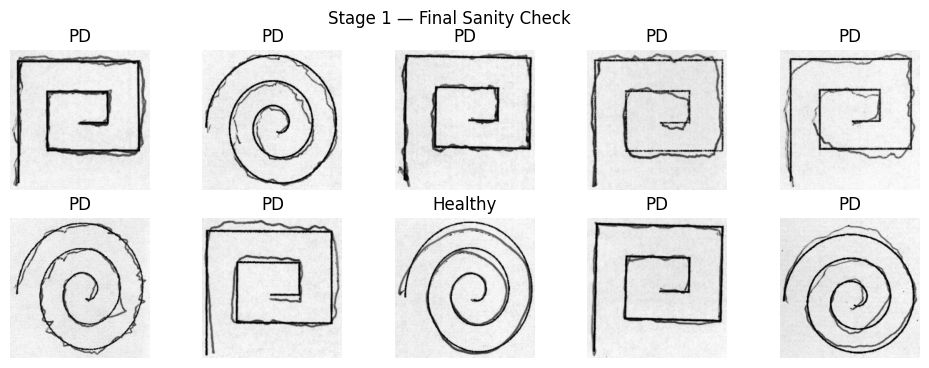

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title("PD" if y_train[i]==1 else "Healthy")
    plt.axis("off")

plt.suptitle("Stage 1 — Final Sanity Check")
plt.show()


In [20]:
import tensorflow as tf
from tensorflow.keras import layers

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        self.projection = layers.Dense(embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        return self.projection(patches)


In [25]:
class PositionalEncoding(layers.Layer):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.num_patches = num_patches
        self.dim = dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, self.num_patches, self.dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos_embedding


In [26]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, name=None):
        super().__init__(name=name)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        # Attention
        x1 = self.norm1(x)
        attn_output = self.attn(x1, x1)
        x = x + self.drop1(attn_output, training=training)

        # MLP
        x2 = self.norm2(x)
        x = x + self.mlp(x2, training=training)

        return x


In [27]:
from tensorflow.keras import Input, Model

def build_custom_vit_feature_extractor():
    inputs = Input(shape=(224, 224, 1))

    # Patch embedding
    x = PatchEmbedding(patch_size=16, embed_dim=526)(inputs)

    # 224/16 = 14 → 14*14 = 196 patches
    x = PositionalEncoding(num_patches=196, dim=526)(x)

    block_count = 0

    # -------- Stage 1: 526 (4 blocks) --------
    for _ in range(4):
        x = TransformerBlock(embed_dim=526, num_heads=8, mlp_dim=1024, dropout=0.1, name=f"transformer_block_{block_count}")(x)
        block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(256)(x)

    # -------- Stage 2: 256 (3 blocks) --------
    for _ in range(3):
        x = TransformerBlock(embed_dim=256, num_heads=8, mlp_dim=512, dropout=0.1, name=f"transformer_block_{block_count}")(x)
        block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(128)(x)

    # -------- Stage 3: 128 (3 blocks) --------
    for _ in range(3):
        x = TransformerBlock(embed_dim=128, num_heads=4, mlp_dim=256, dropout=0.1, name=f"transformer_block_{block_count}")(x)
        block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(64)(x)

    # -------- Stage 4: 64 (2 blocks) --------
    for _ in range(2):
        x = TransformerBlock(embed_dim=64, num_heads=4, mlp_dim=128, dropout=0.1, name=f"transformer_block_{block_count}")(x)
        block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(32)(x)

    # -------- Stage 5: 32 (2 blocks) --------
    for _ in range(2):
        x = TransformerBlock(embed_dim=32, num_heads=2, mlp_dim=64, dropout=0.1, name=f"transformer_block_{block_count}")(x)
        block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(16)(x)

    # -------- Stage 6: 16 (1 block) --------
    x = TransformerBlock(embed_dim=16, num_heads=2, mlp_dim=32, dropout=0.1, name=f"transformer_block_{block_count}")(x)
    block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(8)(x)

    # -------- Stage 7: 8 (1 block) --------
    x = TransformerBlock(embed_dim=8, num_heads=2, mlp_dim=16, dropout=0.1, name=f"transformer_block_{block_count}")(x)
    block_count += 1

    x = layers.LayerNormalization()(x)
    x = layers.Dense(4)(x)

    print("Total Transformer Blocks:", block_count)

    # Final feature vector
    outputs = layers.GlobalAveragePooling1D(name="vit_final_feature")(x)

    return Model(inputs, outputs, name="Custom_ViT_Feature_Extractor")


In [28]:
vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Total Transformer Blocks: 16


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_1               │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_22          │ (None, 196, 128)       │           25

 Total params: 48,499,150 (185.01 MB)

 Trainable params: 48,499,150 (185.01 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.models import Model

feature_model = Model(
    inputs=vit_extractor.input,
    outputs=vit_extractor.get_layer("transformer_block_15").output,
    name="ViT_Block15_Feature_Model"
)

feature_model.summary()


Model: "ViT_Block15_Feature_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_1               │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 526)       │     9,947,684 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 196, 256)       │     2,367,488 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 196, 128)       │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_22          │ (None, 196, 128)       │           25

 Total params: 48,499,098 (185.01 MB)

 Trainable params: 48,499,098 (185.01 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
X_train_block15 = feature_model.predict(X_train, batch_size=16, verbose=1)
X_test_block15  = feature_model.predict(X_test, batch_size=16, verbose=1)

print("Train Block15 Features:", X_train_block15.shape)
print("Test Block15 Features :", X_test_block15.shape)


62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 478ms/step
Train Block15 Features: (990, 196, 8)
Test Block15 Features : (330, 196, 8)


In [31]:
X_train_feat = np.mean(X_train_block15, axis=1)
X_test_feat  = np.mean(X_test_block15, axis=1)

print("Final Train Feature Vector:", X_train_feat.shape)
print("Final Test Feature Vector :", X_test_feat.shape)


Final Train Feature Vector: (990, 8)
Final Test Feature Vector : (330, 8)


In [32]:
from tensorflow.keras import layers, models

fcnn = models.Sequential([
    layers.Input(shape=(X_train_feat.shape[1],)),   # (4,)

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

fcnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fcnn.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_fcnn = fcnn.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7370 - loss: 0.5957 - val_accuracy: 0.7545 - val_loss: 0.5823
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7447 - loss: 0.5825 - val_accuracy: 0.7545 - val_loss: 0.5858
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7281 - loss: 0.5925 - val_accuracy: 0.7545 - val_loss: 0.5813
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7488 - loss: 0.5842 - val_accuracy: 0.7545 - val_loss: 0.5815
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7615 - loss: 0.5810 - val_accuracy: 0.7545 - val_loss: 0.5774
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7585 - loss: 0.5812 - val_accuracy: 0.7576 - val_loss: 0.5769
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7488 - loss: 0.5844 - val_accuracy: 0.7515 - val_loss: 0.5740
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7539 - loss: 0.5836 - val_accuracy: 0.7515 - val_loss: